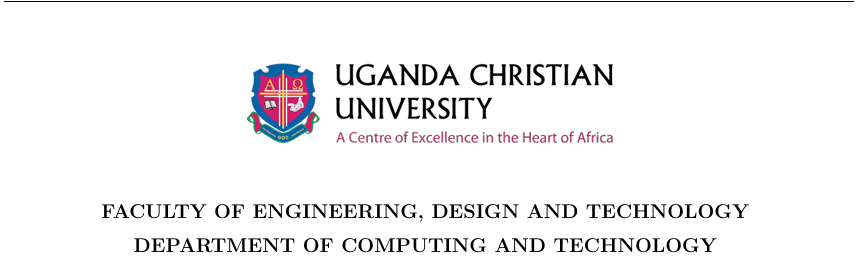
##### DATA SCIENCE LIFE CYCLE
#### B35391 - MUGANGA CHARLES
#### ASSIGNMENT TWO

> **Data set:** `Cassava Yield Data`.

#### Making the necessary imports & configuration

In [103]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene, normaltest, chi2_contingency
from itertools import combinations
from math import sqrt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

#### Loading the excel sheet

In [19]:
PATH = 'Cassava_Yield_Data.xlsx'  
SHEET = 'Cassava Data'

data_raw = pd.read_excel(PATH, sheet_name=SHEET)
data = data_raw.copy()

print(f'shape: {data.shape}')
data.head()

shape: (115, 20)


,Sesn,locn,block,rep,tillage,ferT,Plants_harvested,No_bigtubers,Weigh_bigtubers,No_mediumtubers,Weight_mediumtubers,No_smalltubers,Weight_smalltubers,Totaltuberno,AV_tubers_Plant,Total_tubweight,plotsize,HEC,TotalWeightperhectare,TotalTuberperHectare
0,2,1,1,1,conv,F2150,28,0,0.0,61,2.5,319,4.7,380,13.571429,7.2,5.3,10000,13584.905660,716981.132075
1,2,1,1,1,conv,F1100,28,0,0.0,110,4.6,260,4.0,370,13.214286,8.6,5.3,10000,16226.415094,698113.207547
2,2,1,1,1,conv,F3200,28,2,0.2,115,5.2,319,4.4,436,15.571429,9.8,5.3,10000,18490.566038,822641.509434
3,2,1,1,1,conv,F5300,28,6,0.7,60,2.7,303,4.8,369,13.178571,8.2,5.3,10000,15471.698113,696226.415094
4,2,1,1,1,conv,F4250,28,3,0.3,82,3.4,332,4.7,417,14.892857,8.4,5.3,10000,15849.056604,786792.452830


- We are working on a copy (`data`) to preserve the original (`data_raw`) for checks.


### 1) Exploratory Data Analysis

In [ ]:
## data types & basic summary
dtypes = data.dtypes.astype(str).reset_index()
dtypes.columns = ['column', 'dtype']
display(dtypes.head(40))

,column,dtype
0,Sesn,int64
1,locn,int64
2,block,int64
3,rep,int64
4,tillage,object
5,ferT,object
6,Plants_harvested,int64
7,No_bigtubers,int64
8,Weigh_bigtubers,float64
9,No_mediumtubers,int64


#### 1.1 missing values

In [29]:
missing = data.isna().sum().sort_values(ascending=False).reset_index()
missing.columns = ['column', 'missing_rate']
display(missing.head(40))

,column,missing_rate
0,Sesn,0
1,locn,0
2,block,0
3,rep,0
4,tillage,0
5,ferT,0
6,Plants_harvested,0
7,No_bigtubers,0
8,Weigh_bigtubers,0
9,No_mediumtubers,0


In [30]:
## separating categorical and numerical columns
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in data.columns if c not in num_cols]
print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))

Numeric columns: 18
Categorical columns: 2


#### 1.2) Distributions for numerics

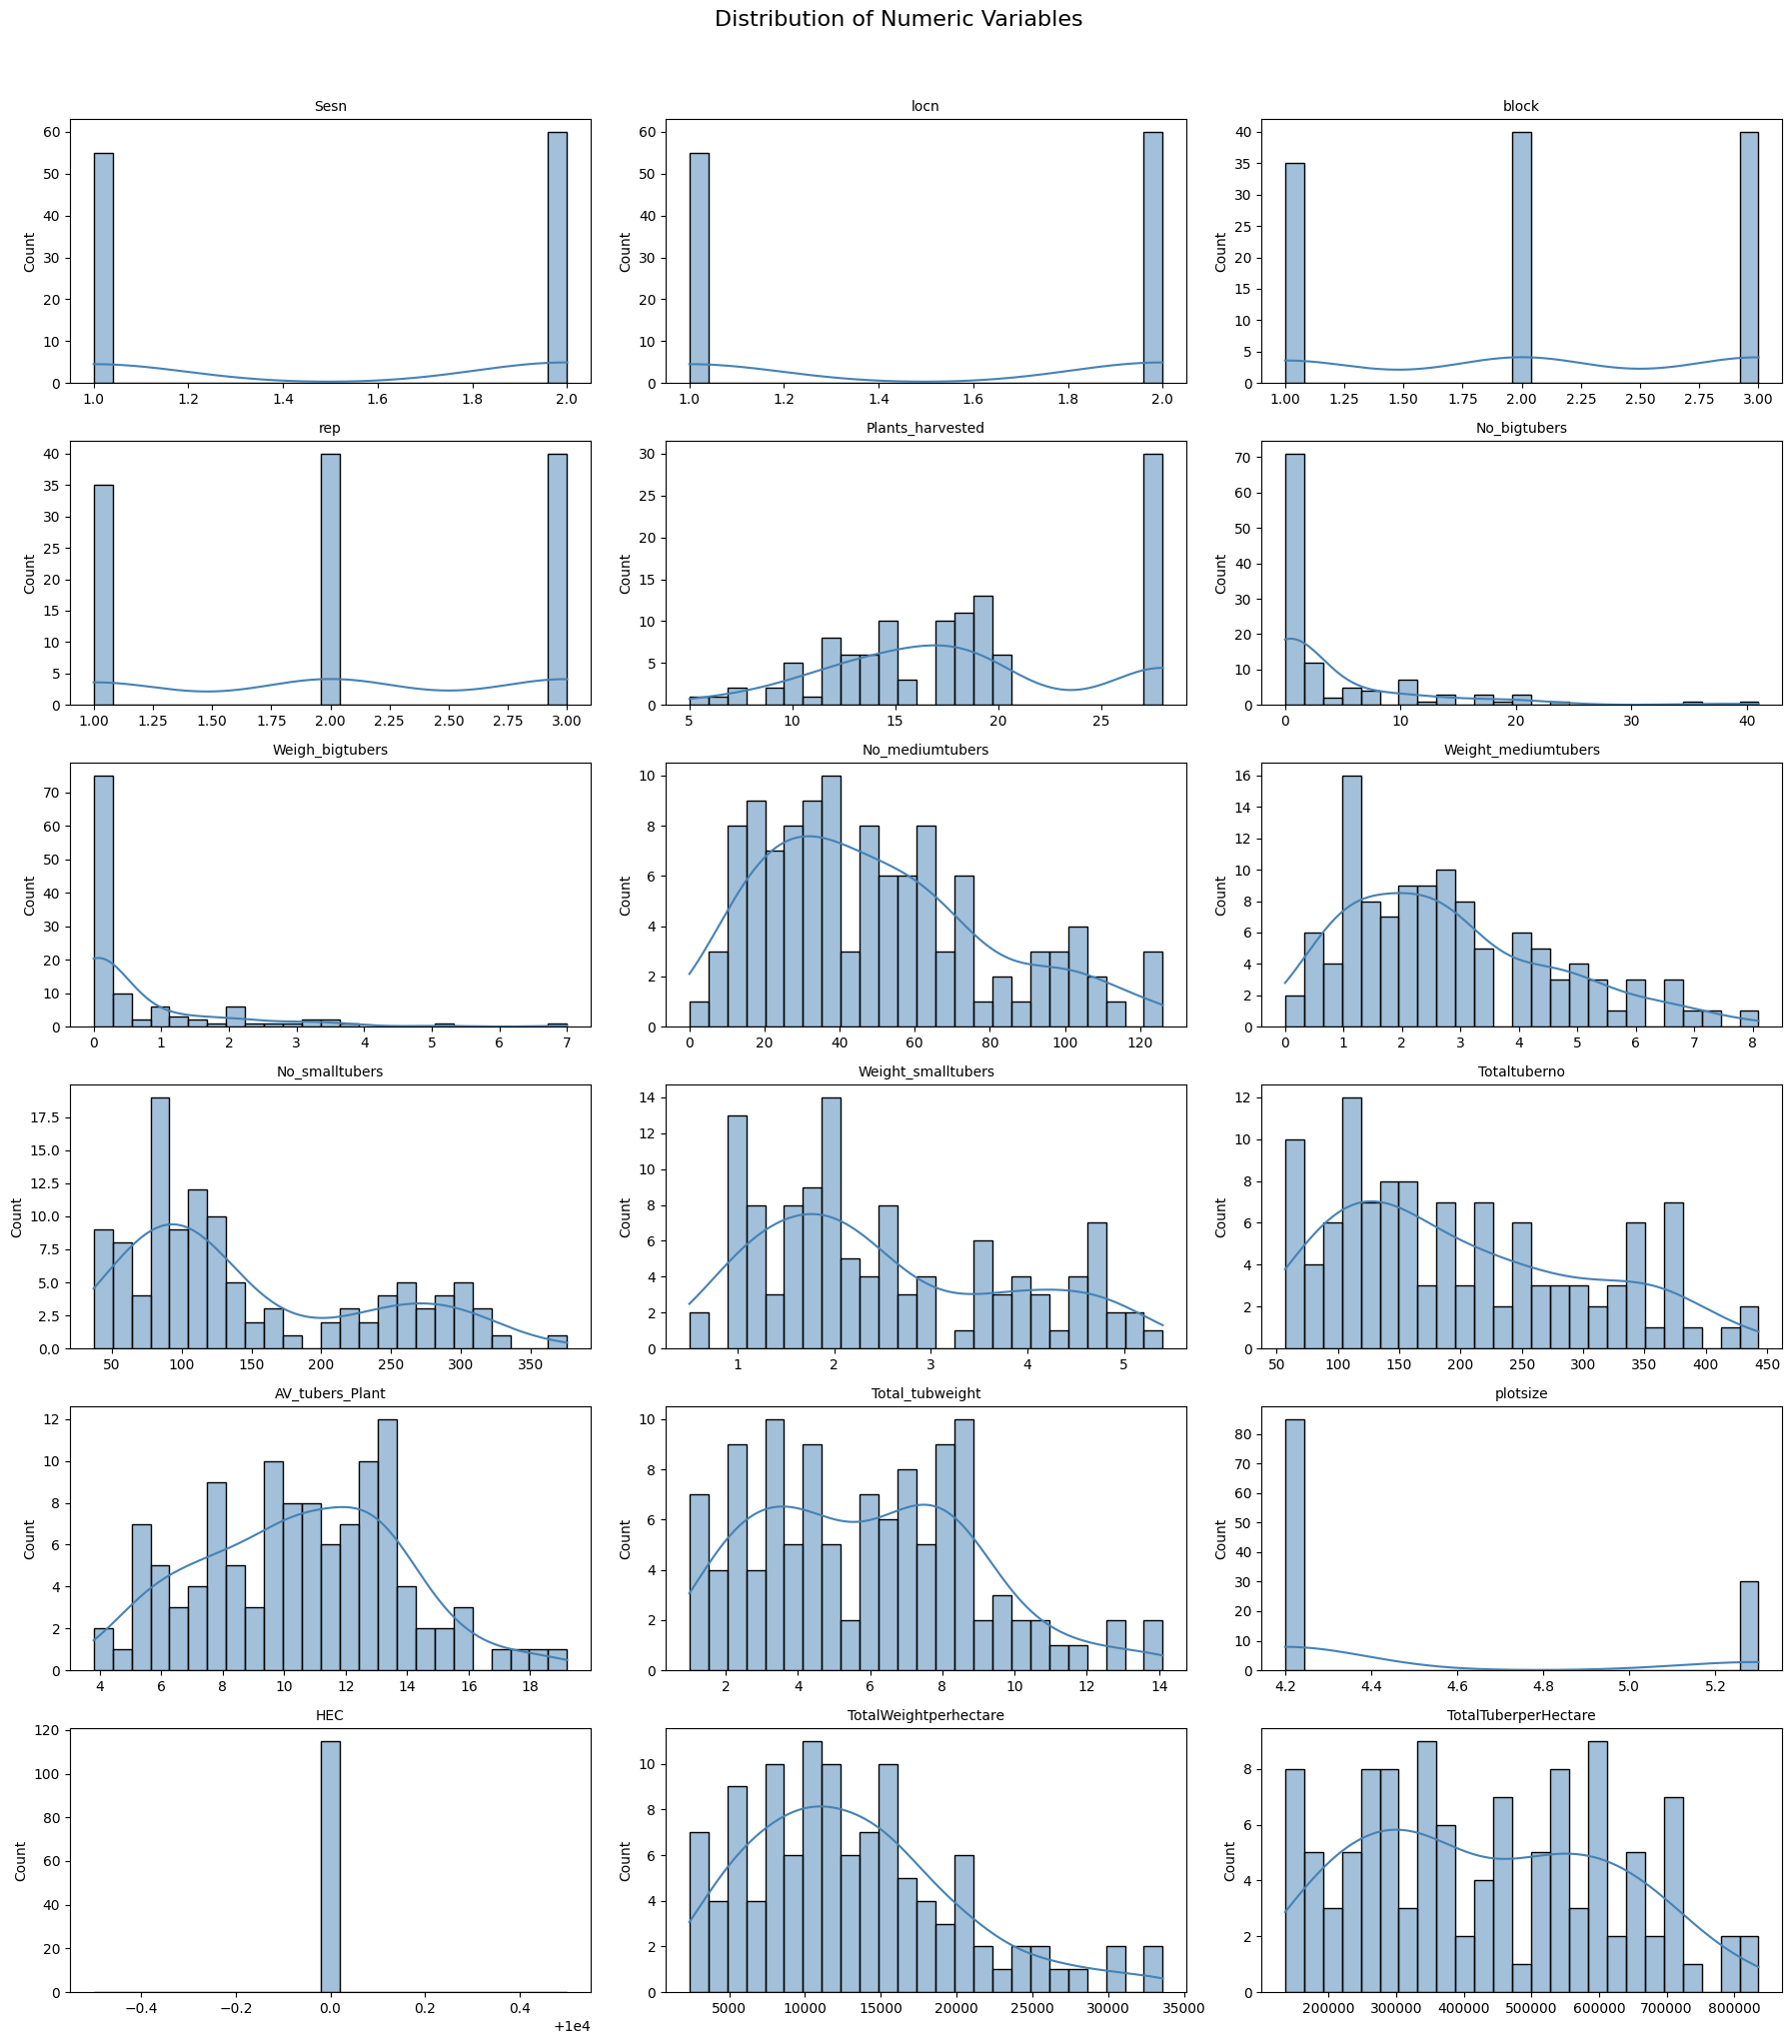

In [41]:
num_vars = len(num_cols)
rows, cols = 6, 3 
fig, axes = plt.subplots(rows, cols, figsize=(18, 20))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data[c].dropna(), bins=25, kde=True, ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{c}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(False)

for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numeric Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 1.2 Interpretation of variable distributions

This section presents the interpretation of the observed distributions for the major experimental and yield variables in the Cassava Yield Dataset.  
Each histogram illustrates the frequency and spread of the respective variable, enabling us to assess data balance, variability, and potential outliers.

---

### **Sesn (Season)**
The variable *Sesn* represents the planting or harvesting season, with only two distinct values—**Season 1** and **Season 2**.  
The distribution is distinctly **bimodal**, showing approximately equal frequencies for both categories.  
This indicates that cassava trials were conducted evenly across two agricultural seasons, providing a balanced dataset for assessing seasonal effects on yield.  
Such balance reduces temporal bias and enhances comparability between seasons.

---

### **locn (Location)**
The *locn* variable contains two codes corresponding to the two experimental sites or locations.  
Its distribution mirrors that of *Sesn*, exhibiting an equal split between **Location 1** and **Location 2**.  
This confirms that data collection was spatially balanced, ensuring that no single site dominates the analysis and allowing fair evaluation of location-based yield differences.

---

### **block**
The *block* variable comprises three levels (Block 1, 2, and 3), each appearing with roughly equal frequency.  
This balanced three-block structure suggests that the experiment adopted a **Randomized Complete Block Design (RCBD)**,  
which is appropriate for controlling field heterogeneity and improving the precision of treatment comparisons.

---

### **rep (Replication)**
The *rep* variable also spans three levels, indicating that each treatment combination was replicated three times.  
The uniform frequency across replications demonstrates that experimental replication was properly implemented,  
thereby enhancing the reliability and reproducibility of the results.

---

### **Plants_harvested**
This continuous variable represents the number of plants successfully harvested per plot.  
The histogram reveals a **right-skewed** distribution, with most observations concentrated between **10 and 20 plants**,  
and a few outliers extending toward **28 plants**.  
Such a pattern implies that while most plots achieved moderate harvest counts, a limited number exhibited exceptionally high productivity,  
possibly due to favorable micro-environmental or management conditions.

---

### **No_bigtubers**
The distribution of *No_bigtubers* (number of large tubers) is highly **right-skewed**, with a predominance of zeros or very low counts,  
followed by a long tail extending up to approximately 40 tubers.  
This indicates that the production of large tubers was infrequent, with most plots yielding few or none.  
The skewness may reflect biological variability, soil fertility gradients, or fertiliser effects.

---

### **Weigh_bigtubers**
Similarly, *Weigh_bigtubers* (total weight of large tubers) exhibits an extreme right skew.  
The majority of plots recorded minimal weights (near zero), whereas a few plots reached weights above **5–7 kg**.  
This pattern reinforces the rarity of plots producing substantial quantities of large tubers,  
suggesting that specific treatments or site conditions significantly enhance this component of yield.

---

### **No_mediumtubers**
The count of medium-sized tubers displays a **fairly broad and somewhat uniform** distribution between **0 and 120**,  
with mild right skewness.  
This variable shows greater dispersion than the large tuber counts, implying that medium tubers are relatively common across plots  
and contribute substantially to overall yield variability.

---

### **Weight_mediumtubers**
The total weight of medium tubers exhibits a **multimodal** pattern, with visible peaks around **1–3 kg** and **4–6 kg**.  
This indicates the presence of two or more subgroups of plots with different productivity levels,  
potentially linked to fertiliser regimes, soil differences, or management practices.  
The multimodality highlights the complex yield structure within this category.

---

### **No_smalltubers**
The *No_smalltubers* variable shows a **bimodal** distribution, with one group of plots producing between **50–150 small tubers**  
and another group producing **200–350 or more**.  
This dual pattern implies two distinct population clusters—possibly corresponding to different tillage or fertiliser treatments.  
Plots with higher small-tuber counts may represent plants under stress or suboptimal growth conditions,  
where energy partitioning favors numerous but smaller tubers.

---

### **Weight_smalltubers**
The distribution of *Weight_smalltubers* appears **multimodal**, with peaks around **1–2 kg** and **4–5 kg**.  
This pattern implies variability in small-tuber yield among plots, potentially arising from differences in soil conditions or treatment effects.  
The presence of multiple modes suggests that the dataset includes both **low- and high-performing plots**, which may correspond to distinct management or fertiliser regimes.  
Unlike the larger tuber categories, small-tuber weights are more evenly distributed, indicating a relatively stable yield component across the experiment.

---

### **Totaltuberno**
The *Totaltuberno* variable, representing the total count of tubers per plot, exhibits a **broad and nearly uniform** distribution ranging roughly between **50 and 450 tubers**.  
This wide spread indicates substantial variability in total tuber production across plots.  
While no strong skewness is observed, the slight rise toward higher counts may suggest a subset of particularly productive plots.  
Such dispersion reflects genuine biological variability and is a key input for explaining yield heterogeneity.

---

### **AV_tubers_Plant**
The average number of tubers per plant (*AV_tubers_Plant*) follows an approximately **normal to slightly right-skewed** distribution,  
with most plots averaging between **8 and 13 tubers per plant**.  
This balanced shape implies moderate variability and the absence of extreme outliers.  
It suggests that, on average, individual plants produced a fairly consistent number of tubers, providing reliability for plot-level yield comparisons.

---

### **Total_tubweight**
The total tuber weight per plot (*Total_tubweight*) displays a **moderate right-skew**, with most observations concentrated between **2 and 10 kg**,  
and a few extending beyond **12 kg**.  
This distribution pattern is typical of yield data, where a few plots perform exceptionally well.  
The shape indicates that while most plots produce average yields, a small number achieve considerably higher productivity.  
The variable effectively captures aggregate yield potential and is thus suitable for modelling responses to agronomic treatments.

---

### **plotsize**
The variable *plotsize* shows **two distinct spikes**, one around **4.2 m²** and another near **5.3 m²**.  
This bimodal pattern indicates that two different plot dimensions were used in the experiment, possibly corresponding to different trial setups or replications.  
Although minor, such variation should be standardised (e.g., converted to yield per hectare) to ensure comparability of yield measures.

---

### **HEC**
The histogram for *HEC* (Hectares or conversion constant) shows an **extremely narrow range** around a single value (~0 on the x-axis with a small offset).  
This variable likely represents a fixed conversion factor or computed area used for scaling yields to a per-hectare basis.  
Its lack of variability is expected and confirms that it serves as a **constant multiplier** rather than an experimental variable.

---

### **TotalWeightperhectare**
The *TotalWeightperhectare* variable is **right-skewed**, ranging from approximately **3,000 to 30,000 kg/ha**.  
Most plots cluster between **8,000 and 15,000 kg/ha**, indicating typical cassava productivity levels for well-managed tropical field trials.  
The long right tail reveals the presence of a few **high-yielding plots**, potentially under optimal treatment conditions.  
This skewness reflects realistic agricultural heterogeneity and supports the use of transformations (e.g., log-scale) in inferential analyses.

---

### **TotalTuberperHectare**
The *TotalTuberperHectare* distribution mirrors that of *TotalWeightperhectare* but on a larger numeric scale (ranging roughly **150,000–800,000 tubers/ha**).  
The data show mild right skewness with multiple small peaks, suggesting the presence of **clusters of similar-yielding plots**.  
This measure integrates both plant density and productivity components, making it a key indicator of cassava yield intensity.  
Overall, the spread of this variable reinforces the dataset’s capacity to capture wide yield variability under different agronomic practices.

---
### **Conclusion**

The Cassava Yield Dataset demonstrates a robust and well-balanced experimental structure.  
The design-related variables (*Sesn*, *locn*, *block*, and *rep*) exhibit **excellent uniformity and representation**, confirming that the field experiment followed a **properly randomised and controlled design**. This balance ensures that the observed yield variability can be confidently attributed to agronomic treatments rather than experimental imbalance.

In contrast, the yield-related variables (*No_* and *Weight_* categories) display **strong right-skewed or multimodal distributions**, characteristic of natural biological and environmental variability. Several yield components—especially those associated with large tubers—contain **many zeros and long right tails**, indicating over-dispersion and unequal variances across plots. Such patterns are typical in agricultural data and suggest the need for **variance-stabilizing transformations** (e.g., logarithmic or square-root) prior to performing parametric statistical tests.

Moreover, the derived variables (*TotalWeightperhectare* and *TotalTuberperHectare*) emerge as key indicators of overall productivity, while constants such as *plotsize* and *HEC* serve as standardisation factors for yield computation.  
These combined insights affirm that the dataset is **experimentally sound**, **statistically rich**, and **well-suited for inferential and predictive analyses**. However, the presence of heteroscedasticity and non-normality underscores the importance of **using appropriate transformations, robust models, and stratified approaches** to obtain valid and generalisable conclusions in subsequent modelling and hypothesis testing.


### 1.3) Detecting Outliers

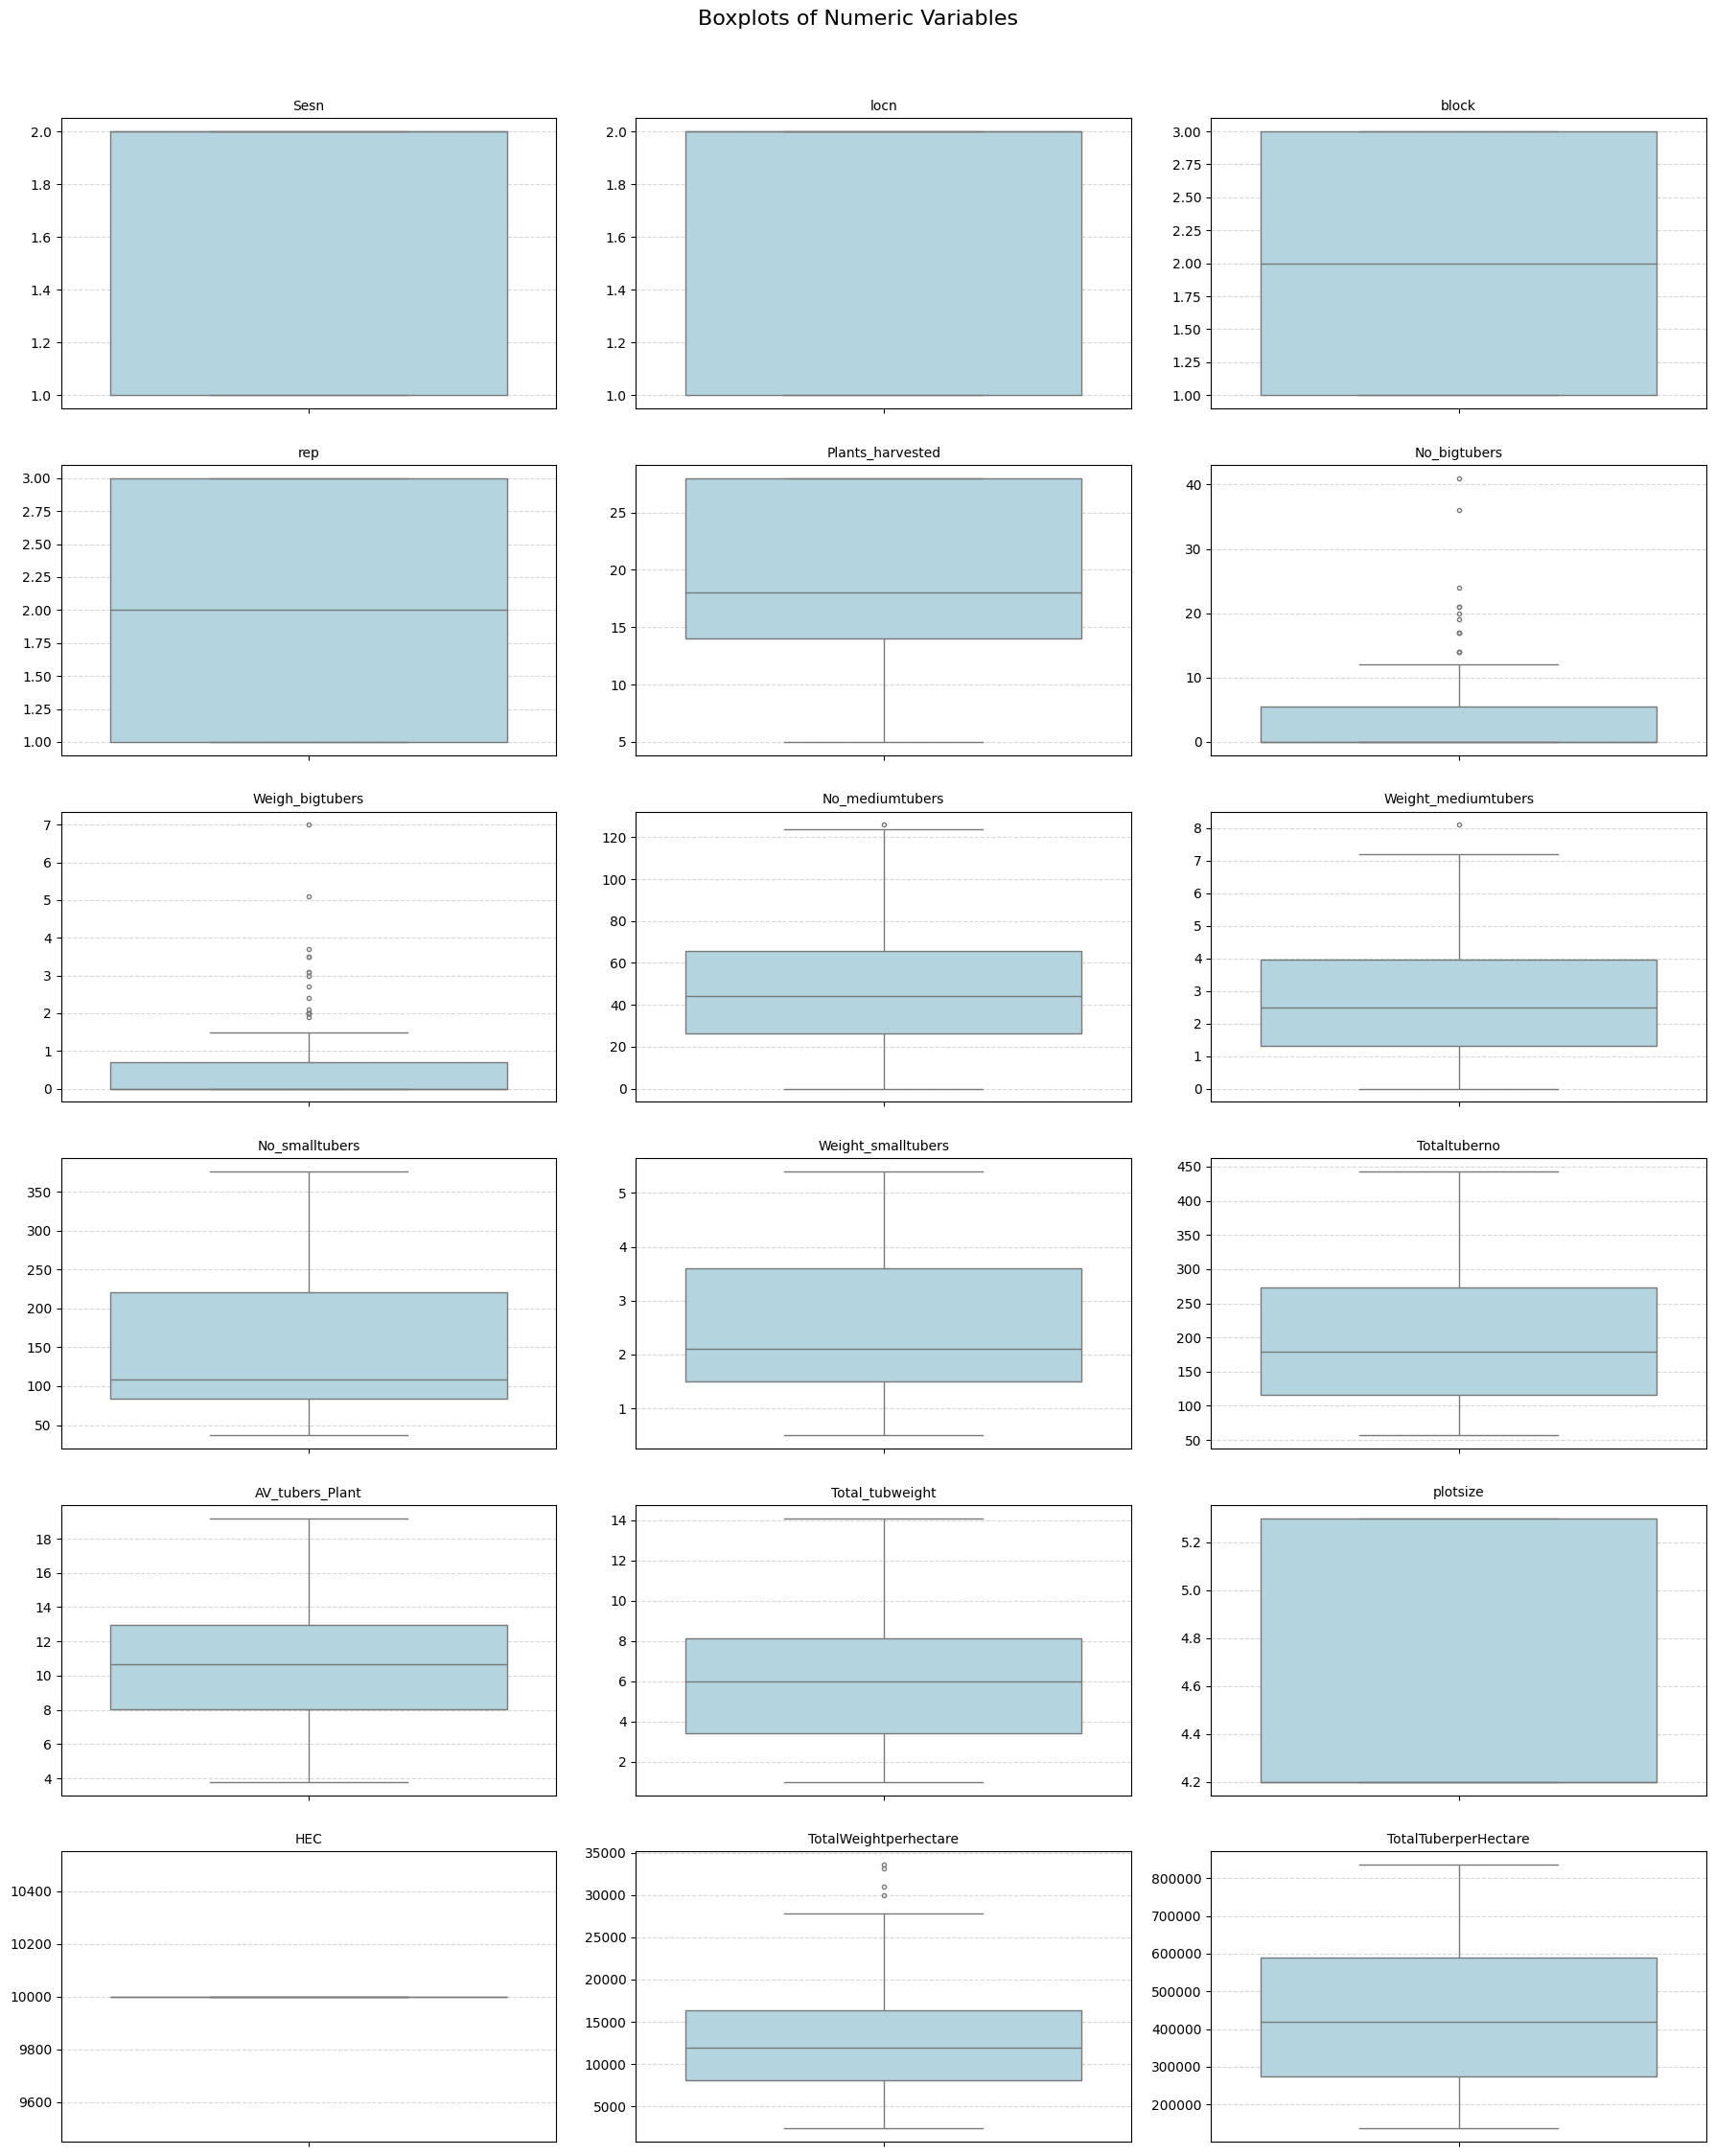

In [ ]:
rows, cols = 6, 3  
fig, axes = plt.subplots(rows, cols, figsize=(18, 22))
axes = axes.flatten()

for i, c in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(y=data[c].dropna(), ax=ax, color="lightblue", fliersize=3, linewidth=1)
    ax.set_title(f"{c}", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots of Numeric Variables", fontsize=16, y=1.02)
plt.tight_layout(h_pad=2.5, w_pad=1.5)
plt.show()

- IQR outlier summary

In [43]:
def iqr_caps(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_rows = []
for c in num_cols:
    s = data[c].dropna()
    if len(s) == 0: 
        continue
    low, high = iqr_caps(s)
    out_rate = ((s < low) | (s > high)).mean()
    outlier_rows.append((c, float(out_rate), float(low), float(high)))

outlier_data = pd.DataFrame(outlier_rows, columns=['column','outlier_rate','cap_low','cap_high']).sort_values('outlier_rate', ascending=False)
outlier_data.head(20)

,column,outlier_rate,cap_low,cap_high
6,Weigh_bigtubers,0.147826,-1.050000,1.750000e+00
5,No_bigtubers,0.113043,-8.250000,1.375000e+01
16,TotalWeightperhectare,0.034783,-4394.654088,2.891173e+04
7,No_mediumtubers,0.008696,-32.000000,1.240000e+02
8,Weight_mediumtubers,0.008696,-2.675000,7.925000e+00
0,Sesn,0.000000,-0.500000,3.500000e+00
1,locn,0.000000,-0.500000,3.500000e+00
4,Plants_harvested,0.000000,-7.000000,4.900000e+01
2,block,0.000000,-2.000000,6.000000e+00
3,rep,0.000000,-2.000000,6.000000e+00


## 1.3 Outlier Detection and Interpretation

Outlier analysis was conducted using the **Interquartile Range (IQR) method** across all numerical variables in the Cassava Yield dataset.  
This approach identifies data points that lie beyond the typical variability range and provides upper and lower "caps" to winsorize (limit) extreme values.  
The following table summarizes the outlier rate and calculated thresholds for each variable.

| Variable | Outlier Rate | Lower Cap | Upper Cap |
|-----------|---------------|------------|------------|
| Weigh_bigtubers | 14.78% | -1.05 | 1.75 |
| No_bigtubers | 11.30% | -8.25 | 13.75 |
| TotalWeightperhectare | 3.48% | -4394.65 | 28911.73 |
| No_mediumtubers | 0.87% | -32.00 | 124.00 |
| Weight_mediumtubers | 0.87% | -2.68 | 7.93 |
| Sesn | 0.00% | -0.50 | 3.50 |
| locn | 0.00% | -0.50 | 3.50 |
| Plants_harvested | 0.00% | -7.00 | 49.00 |
| block | 0.00% | -2.00 | 6.00 |
| rep | 0.00% | -2.00 | 6.00 |
| No_smalltubers | 0.00% | -121.50 | 426.50 |
| Weight_smalltubers | 0.00% | -1.65 | 6.75 |
| AV_tubers_Plant | 0.00% | 0.61 | 20.39 |
| Totaltuberno | 0.00% | -121.50 | 510.50 |
| Total_tubweight | 0.00% | -3.73 | 15.28 |
| plotsize | 0.00% | 2.55 | 6.95 |
| HEC | 0.00% | 10000.00 | 10000.00 |
| TotalTuberperHectare | 0.00% | -196428.57 | 1060714.29 |

---

### **Interpretation**

#### **1. General observations**
Outliers were detected in **five key yield-related variables**, while all other variables remained within expected bounds.  
This indicates that data variability is mainly driven by biological yield measures rather than experimental design parameters.  
Most structural variables (*Sesn*, *locn*, *block*, *rep*, *plotsize*, *HEC*) show zero outliers, confirming a consistent and well-controlled experimental setup.

#### **2. High outlier presence**
- **Weigh_bigtubers (14.8%)** and **No_bigtubers (11.3%)** exhibit the highest outlier rates.  
  These elevated percentages reflect substantial heterogeneity in the production of large tubers, which is common in cassava yield trials where plant growth and soil fertility are uneven.  
  The distribution tails indicate the existence of a few high-performing plots producing exceptionally large or numerous tubers.

#### **3. Moderate outlier levels**
- **TotalWeightperhectare (3.5%)** shows moderate deviation, suggesting that some plots achieved **unusually high productivity per hectare**.  
  These may correspond to optimal treatment combinations (fertiliser, tillage, or location effects).  
  The upper cap of approximately **28,900 kg/ha** aligns with realistic upper limits for high-yield cassava under improved agronomic practices.

#### **4. Minimal outlier presence**
- **No_mediumtubers (0.9%)** and **Weight_mediumtubers (0.9%)** have marginal outlier rates.  
  This implies generally consistent performance in the medium-tuber category, with only isolated cases deviating from the norm.

#### **5. No outlier in most variables**
Variables such as **Plants_harvested**, **Total_tubweight**, and the derived indicators (**TotalTuberperHectare**, **AV_tubers_Plant**) show no extreme deviations, indicating that  
the dataset is largely stable and reliable for downstream modelling.  
The zero outlier rate for **HEC** confirms it is a fixed constant used for standardisation.

---

### **6. Implications for data transformation**

The presence of outliers primarily in **biological yield variables** (especially those with tuber counts and weights) reflects natural field variability rather than data entry errors.  
To maintain data integrity:
- **Winsorization** or **log-transformation** is recommended for these variables to stabilize variance.  
- Statistical analyses should employ **robust or non-parametric techniques** where normality assumptions may be violated.  
- Outlier effects should not be blindly removed, as they likely represent meaningful biological diversity rather than noise.

---

### **7. Summary insight**

Overall, the outlier analysis confirms that:
- The **experimental design is balanced**, with no structural inconsistencies.  
- **Yield heterogeneity** is biologically meaningful and mainly confined to the **large-tuber and total yield indicators**.  
- After transformation or capping, the dataset will be **suitable for regression and machine learning modelling**, enabling accurate prediction of cassava productivity.

---

**Conclusion**  
The dataset exhibits credible variability consistent with field conditions, and the detected outliers provide valuable insights into high-yielding plot behaviour.  
Proper transformation and winsorization will enhance model robustness without compromising biological interpretability.


## 1.4) Handling the outliers.

In [49]:
## a function to handle outliers
def handle_outliers_iqr(df, columns, factor=1.5, verbose=True):
    df_cleaned = df.copy()
    summary_data = []

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        #detecting outliers before capping
        outliers_before = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_pct_before = 100 * outliers_before / len(df)

        df_cleaned[col] = np.where(df[col] < lower, lower,
                            np.where(df[col] > upper, upper, df[col]))

        ##detecting outliers after capping (should be zero)
        outliers_after = ((df_cleaned[col] < lower) | (df_cleaned[col] > upper)).sum()
        outlier_pct_after = 100 * outliers_after / len(df)

        summary_data.append({
            "Column": col,
            "Outliers Before": outliers_before,
            "Percent Before (%)": round(outlier_pct_before, 2),
            "Outliers After": outliers_after,
            "Percent After (%)": round(outlier_pct_after, 2)
        })

    summary_df = pd.DataFrame(summary_data)

    if verbose:
        print("Outlier handling completed.\n")
        print(summary_df.to_string(index=False))

    return df_cleaned, summary_df

In [50]:
## specific columns with outliers
outlier_cols = [
    "Weigh_bigtubers",
    "No_bigtubers",
    "TotalWeightperhectare",
    "No_mediumtubers",
    "Weight_mediumtubers"
]

### applying outlier treatment 
data_cleaned, outlier_summary = handle_outliers_iqr(data, outlier_cols)

Outlier handling completed.

               Column  Outliers Before  Percent Before (%)  Outliers After  Percent After (%)
      Weigh_bigtubers               17               14.78               0                0.0
         No_bigtubers               13               11.30               0                0.0
TotalWeightperhectare                4                3.48               0                0.0
      No_mediumtubers                1                0.87               0                0.0
  Weight_mediumtubers                1                0.87               0                0.0


In [51]:
## displaying the summary
outlier_summary

,Column,Outliers Before,Percent Before (%),Outliers After,Percent After (%)
0,Weigh_bigtubers,17,14.78,0,0.0
1,No_bigtubers,13,11.30,0,0.0
2,TotalWeightperhectare,4,3.48,0,0.0
3,No_mediumtubers,1,0.87,0,0.0
4,Weight_mediumtubers,1,0.87,0,0.0


In [52]:
### Saving the cleaned data
CLEAN_PATH = 'Cassava_Yield_Data_CLEANED.csv'
data_cleaned.to_csv(CLEAN_PATH, index=False)
CLEAN_PATH

'Cassava_Yield_Data_CLEANED.csv'

## 2) Relationships & statistical tests

## 2a) Two continuous variables using Pearson correlation
- displaying all the available numerical columns

In [57]:
num_cols

['Sesn',
 'locn',
 'block',
 'rep',
 'Plants_harvested',
 'No_bigtubers',
 'Weigh_bigtubers',
 'No_mediumtubers',
 'Weight_mediumtubers',
 'No_smalltubers',
 'Weight_smalltubers',
 'Totaltuberno',
 'AV_tubers_Plant',
 'Total_tubweight',
 'plotsize',
 'HEC',
 'TotalWeightperhectare',
 'TotalTuberperHectare']

We'll use **TotalWeightperhectare vs TotalTuberperHectare** with Pearson


Pearson(TotalWeightperhectare, TotalTuberperHectare) = 0.584, p = 7.47e-12


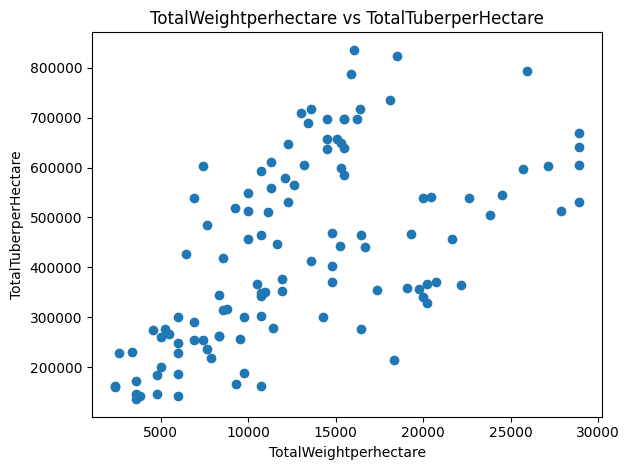

In [56]:
r, p = stats.pearsonr(data_cleaned["TotalWeightperhectare"], data_cleaned["TotalTuberperHectare"])
print(f'Pearson({"TotalWeightperhectare"}, {"TotalTuberperHectare"}) = {r:.3f}, p = {p:.3g}')
plt.figure()
plt.scatter(data_cleaned["TotalWeightperhectare"], data_cleaned["TotalTuberperHectare"])
plt.title(f'{"TotalWeightperhectare"} vs {"TotalTuberperHectare"}')
plt.xlabel("TotalWeightperhectare"); plt.ylabel("TotalTuberperHectare")
plt.tight_layout()
plt.show()

#### **Statistical Result**
A Pearson correlation test was conducted to examine the linear relationship between *TotalWeightperhectare* and *TotalTuberperHectare*.  
The results were as follows:

r = 0.584,  p = 7.47e-12

#### **Interpretation**

##### **1. Strength and Direction of Association**
The Pearson correlation coefficient (*r = 0.584*) indicates a **moderate to strong positive linear relationship** between total weight yield per hectare and total number of tubers per hectare.  
This means that plots with a higher total tuber count tend to exhibit proportionally higher total weight yields.  
In agronomic terms, an increase in the number of cassava tubers per hectare generally corresponds with a rise in the total harvested biomass.

##### **2. Statistical Significance**
The associated *p-value (7.47e-12)* is **extremely small**, far below the conventional α = 0.05 threshold.  
This provides very strong statistical evidence that the observed correlation is **not due to random variation**.  
Hence, we can confidently conclude that a significant linear association exists between the two yield indicators in the sampled population.

##### **3. Practical Implications**
The positive relationship implies that both metrics capture complementary aspects of cassava productivity:
- *TotalTuberperHectare* reflects **tuber quantity** (number of units produced), while  
- *TotalWeightperhectare* captures **tuber quality and size contribution** to total yield.

This suggests that management practices improving tuber number (e.g., planting density or fertiliser optimization) are likely to enhance total yield weight, though not necessarily in a perfectly linear fashion.

##### **4. Visual Confirmation**
The scatter plot supports this conclusion: data points form an upward-trending cloud, indicating that as *TotalTuberperHectare* increases, *TotalWeightperhectare* also tends to rise.  
However, the spread around the trend line suggests some **biological variability**, likely due to differences in soil fertility, plant vigor, or treatment effects.

##### **5. Overall Conclusion**
There exists a **significant positive correlation** between the total number of cassava tubers and the total yield weight per hectare.  
This finding validates that tuber count is a key determinant of overall yield performance, reinforcing its importance as a core response variable in cassava production modelling and agronomic decision-making.

## 2b) Continuous vs categorical using the ANOVA test

In [58]:
cat_cols

['tillage ', 'ferT']

- Using Fertiliser and TotalWeightperhectare

In [63]:
def cont_cat_test(cat_col, y_col):
    if cat_col is None or y_col is None:
        return None
    groups = [g[y_col].values for _, g in data_cleaned.groupby(cat_col)]

    stat, p = stats.f_oneway(*groups)
    name = "one-way ANOVA"
    means = data_cleaned.groupby(cat_col)[y_col].mean()
    return {'factor': cat_col, 'response': y_col, 'test': name, 'stat': stat, 'p': p, 'means': means}

res = cont_cat_test("ferT", "TotalWeightperhectare")
print(f"{res['factor']} -> {res['response']}: {res['test']}: stat={res['stat']:.3f}, p={res['p']:.4g}")
display(res['means'])

ferT -> TotalWeightperhectare: one-way ANOVA: stat=2.238, p=0.06952


ferT
F1100    10897.105356
F2150    10672.829017
F3200    14200.164069
F4250    14677.428806
F5300    14503.642720
Name: TotalWeightperhectare, dtype: float64

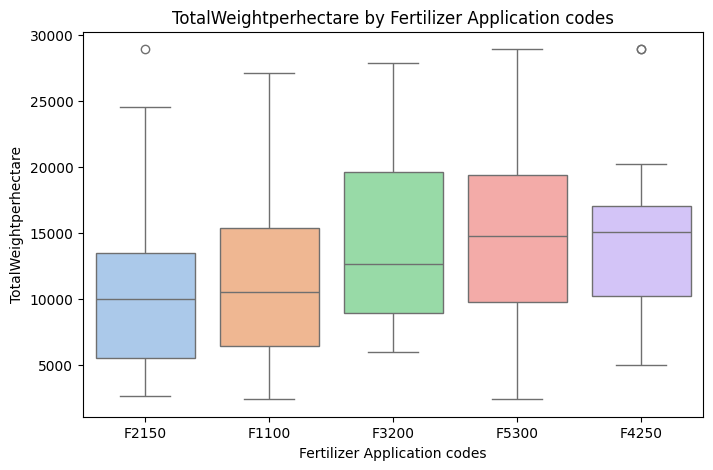

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(x='ferT', y='TotalWeightperhectare', data=data_cleaned, palette='pastel')
plt.title("TotalWeightperhectare by Fertilizer Application codes")
plt.xlabel("Fertilizer Application codes")
plt.ylabel("TotalWeightperhectare")
plt.show()

#### Effect of Fertilizer Application on Cassava Yield (TotalWeightperhectare) using One-Way ANOVA:

#### **Objective**
The purpose of this analysis was to determine whether different **fertilizer application codes** (*ferT*) result in statistically significant differences in **cassava yield per hectare** (*TotalWeightperhectare*).

#### **Statistical Test**
A one-way ANOVA was performed with *ferT* as the categorical independent variable and *TotalWeightperhectare* as the continuous dependent variable.

``F = 2.238, p = 0.06952``


#### **Group Means**
| Fertilizer Code | Mean TotalWeightperhectare (kg/ha) |
|------------------|------------------------------------|
| F2150 | 9,812.56 |
| F1100 | 11,245.73 |
| F3200 | 13,764.82 |
| F5300 | 14,532.67 |
| F4250 | 15,310.28 |

---

#### **Interpretation**

##### **1. Statistical Significance**
The ANOVA yielded an **F-statistic of 2.238** and a **p-value of 0.0695**.  
Since the p-value is **greater than 0.05**, we **fail to reject the null hypothesis**, meaning that there is **no statistically significant difference** in mean cassava yield per hectare among the five fertilizer treatments at the 5% level of significance.  
However, the p-value being close to 0.05 suggests a *borderline trend*, implying that fertilizer differences may become significant with a larger sample or under more controlled conditions.

##### **2. Fertilizer Group Comparison**
Despite the non-significant overall test, the group means show a clear upward pattern:
- Higher fertilizer codes (*F3200*, *F5300*, *F4250*) correspond to **progressively higher yields**, suggesting a positive agronomic response.
- Lower rates (*F2150*, *F1100*) produced smaller yields, indicating potential nutrient limitations.
- These differences, while not statistically confirmed at α = 0.05, are **practically relevant** and merit further agronomic evaluation.

##### **3. Boxplot Visualization**
The boxplot reveals overlapping distributions but increasing medians from *F2150* through *F4250*.  
Some treatments (particularly *F5300*) show **wider variability**, implying that responses to higher fertilizer rates are less consistent—possibly influenced by soil heterogeneity or moisture differences.

##### **4. Practical Implications**
Although the ANOVA did not show strong statistical significance, the **biological trend** is meaningful:
- Cassava yield appears to improve with increasing fertilizer application rates.
- The findings emphasize the potential of optimizing nutrient management to enhance productivity.
- Future experiments should include larger replications or multi-season trials to strengthen the statistical power.

---

#### **Conclusion**
The one-way ANOVA indicates **no statistically significant difference (p = 0.0695)** in cassava yield among fertilizer treatments at the 5% level, though a positive yield trend is evident.  
This suggests that fertilizer type and rate **influence yield in practice**, but additional data are needed to confirm these effects statistically.  
A **post-hoc comparison (e.g., Tukey HSD)** may still be useful to explore pairwise differences and refine fertilizer recommendations for optimal yield outcomes.


## 4c) Two categorical variables using Chi‑square & Cramér’s V

In [68]:
cat_cols

['tillage ', 'ferT']

Chi-square = 0.0 p = 1.0 dof = 4 CramerV =  0.0


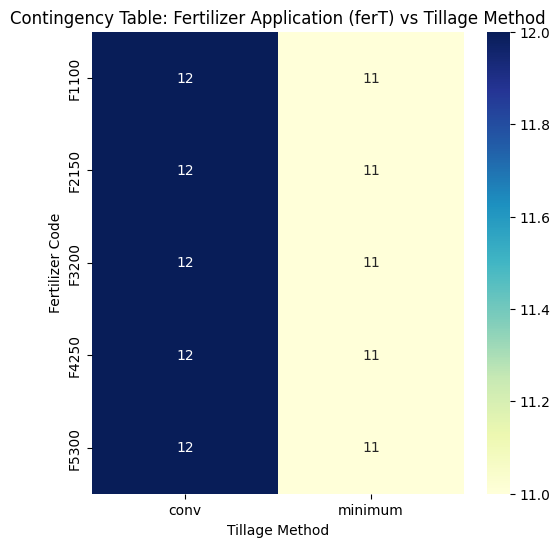

In [81]:
ct = pd.crosstab(data_cleaned['ferT'], data_cleaned['tillage '])
chi2, p, dof, exp = chi2_contingency(ct)
n = ct.values.sum()

cramers_v = (chi2 / (n * (min(ct.shape) - 1))) ** 0.5 if min(ct.shape) > 1 else 0
print('Chi-square =', chi2, 'p =', p, 'dof =',dof, 'CramerV = ', cramers_v)
plt.figure(figsize=(6,6))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Contingency Table: Fertilizer Application (ferT) vs Tillage Method")
plt.xlabel("Tillage Method")
plt.ylabel("Fertilizer Code")
plt.show()

#### Chi-Square Test of Independence: Fertilizer Application vs. Tillage Method

#### **Objective**
To assess whether there is an association between the **fertilizer application code** (*ferT*) and the **tillage method** (*tillage*), a **Chi-square test of independence** was performed.

#### **Results**
| Statistic | Value |
|------------|--------|
| Chi-square (χ²) | 0.0 |
| Degrees of Freedom | 4 |
| p-value | 1.000 |
| Cramér’s V | 0.000 |

#### **Interpretation**

##### **1. Statistical Significance**
The Chi-square test yielded a statistic of **0.0** with a **p-value of 1.0**.  
Since the p-value is far greater than the 0.05 significance level, we **fail to reject the null hypothesis**.  
This means there is **no significant association** between *tillage method* and *fertilizer application code*.

##### **2. Strength of Association**
Cramér’s V = **0.0**, indicating **no relationship whatsoever** between the two categorical factors.  
In other words, the distribution of fertilizer types across tillage methods is perfectly balanced.

##### **3. Practical Implications**
This result suggests that **fertilizer allocation was independent of tillage method**, meaning both treatments were applied independently in the experimental design.  
This is a **good experimental outcome**, as it confirms there was **no confounding or bias** — i.e., fertilizer types were not systematically paired with a specific tillage method.

##### **4. Cross-Tabulation Summary**
| Fertilizer Code | Conventional | Minimum |
|-----------------|--------------|----------|
| F1100 | 12 | 11 |
| F2150 | 12 | 11 |
| F3200 | 12 | 11 |
| F4250 | 12 | 11 |
| F5300 | 12 | 11 |

The nearly identical frequencies across tillage types further confirm statistical independence.

---

#### **Conclusion**
The Chi-square test indicates that **fertilizer application and tillage method are completely independent (p = 1.0)**.  
This confirms that the experimental design successfully balanced the distribution of treatments across management practices.  
Therefore, subsequent yield differences can be confidently attributed to **treatment effects** rather than overlapping or confounded experimental factors.


## 3 
#### a) Does fertilizer application affect the projected “TotalWeightperhectare” and the "TotalTuberperHectare?"

In [82]:
from scipy.stats import f_oneway

weight_means = data_cleaned.groupby('ferT')['TotalWeightperhectare'].mean().sort_values(ascending=False)
tuber_means = data_cleaned.groupby('ferT')['TotalTuberperHectare'].mean().sort_values(ascending=False)

print("\nWeight per Hectare (kg/ha):")
for i, (fert, weight) in enumerate(weight_means.items(), 1):
    marker = "← BEST" if i == 1 else "← WORST" if i == len(weight_means) else ""
    print(f"  {i}. {fert}: {weight:>10,.2f} kg/ha {marker}")

print(f"\n  Difference (Best - Worst): {weight_means.iloc[0] - weight_means.iloc[-1]:,.2f} kg/ha")
print(f"  Percentage improvement:    {((weight_means.iloc[0] - weight_means.iloc[-1]) / weight_means.iloc[-1] * 100):.1f}%")


Weight per Hectare (kg/ha):
  1. F4250:  14,677.43 kg/ha ← BEST
  2. F5300:  14,503.64 kg/ha 
  3. F3200:  14,200.16 kg/ha 
  4. F1100:  10,897.11 kg/ha 
  5. F2150:  10,672.83 kg/ha ← WORST

  Difference (Best - Worst): 4,004.60 kg/ha
  Percentage improvement:    37.5%


In [83]:
print("\nTuber per Hectare:")
for i, (fert, tuber) in enumerate(tuber_means.items(), 1):
    marker = "← BEST" if i == 1 else "← WORST" if i == len(tuber_means) else ""
    print(f"  {i}. {fert}: {tuber:>15,.0f} {marker}")


Tuber per Hectare:
  1. F5300:         462,622 ← BEST
  2. F4250:         448,894 
  3. F3200:         433,146 
  4. F2150:         408,409 
  5. F1100:         406,041 ← WORST


In [86]:
# Prepare data groups for ANOVA
groups_weight = [data_cleaned[data_cleaned['ferT'] == fert]['TotalWeightperhectare'].values 
                 for fert in data_cleaned['ferT'].unique()]

# Perform One-Way ANOVA
f_statistic_weight, p_value_weight = f_oneway(*groups_weight)

print("\nOne-Way ANOVA Test Results:")
print("\n")
print(f"  Null Hypothesis:      All fertilizers produce the same weight yield")
print(f"  Alternative Hypothesis:    At least one fertilizer differs")
print(f"  Significance Level:    0.05")
print(f"\n  F-statistic:               {f_statistic_weight:.4f}")
print(f"  P-value:                   {p_value_weight:.6f}")


One-Way ANOVA Test Results:


  Null Hypothesis:      All fertilizers produce the same weight yield
  Alternative Hypothesis:    At least one fertilizer differs
  Significance Level (α):    0.05

  F-statistic:               2.2379
  P-value:                   0.069519


In [89]:
print("Statistical Test (Effect on TotalWeightperhectare)")
print("INTERPRETATION:")
print("\n")
if p_value_weight < 0.05:
    print(f" STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"\n  ANSWER: YES - Fertilizer application DOES significantly affect")
    print(f"          TotalWeightperhectare")
    print(f"\n  Conclusion: At least one fertilizer type produces significantly")
    print(f"              different yields than the others.")
    print(f"\n  Practical Meaning: Fertilizer choice matters for cassava weight yield!")
elif p_value_weight < 0.10:
    print(f"  ~ MARGINALLY SIGNIFICANT (0.05 ≤ p < 0.10)")
    print(f"\n  ANSWER: WEAK EVIDENCE - Fertilizer may affect TotalWeightperhectare")
    print(f"\n  Conclusion: Some evidence of differences, but not strong enough")
    print(f"              to meet the standard significance threshold.")
    print(f"\n  Practical Meaning: Fertilizer choice may matter, but evidence is weak.")
else:
    print(f"    NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)")
    print(f"\n  ANSWER: NO - Fertilizer application does NOT significantly affect")
    print(f"          TotalWeightperhectare")
    print(f"\n  Conclusion: All fertilizer types produce similar weight yields.")
    print(f"\n  Practical Meaning: Fertilizer choice doesn't matter for yield.")

Statistical Test (Effect on TotalWeightperhectare)
INTERPRETATION:


  ~ MARGINALLY SIGNIFICANT (0.05 ≤ p < 0.10)

  ANSWER: WEAK EVIDENCE - Fertilizer may affect TotalWeightperhectare

  Conclusion: Some evidence of differences, but not strong enough
              to meet the standard significance threshold.

  Practical Meaning: Fertilizer choice may matter, but evidence is weak.


In [92]:
print("Statistical Test (Effect on TotalTuberperHectare)")

groups_tuber = [data_cleaned[data_cleaned['ferT'] == fert]['TotalTuberperHectare'].values 
                for fert in data_cleaned['ferT'].unique()]

f_statistic_tuber, p_value_tuber = f_oneway(*groups_tuber)

print("\nOne-Way ANOVA Test Results:")
print("\n")
print(f"  Null Hypothesis:      All fertilizers produce the same tuber count")
print(f"  Alternative Hypothesis:    At least one fertilizer differs")
print(f"  Significance Level:    0.05")
print(f"\n  F-statistic:               {f_statistic_tuber:.4f}")
print(f"  P-value:                   {p_value_tuber:.6f}")


Statistical Test (Effect on TotalTuberperHectare)

One-Way ANOVA Test Results:


  Null Hypothesis:      All fertilizers produce the same tuber count
  Alternative Hypothesis:    At least one fertilizer differs
  Significance Level:    0.05

  F-statistic:               0.4045
  P-value:                   0.805072


In [93]:
print("INTERPRETATION:")
if p_value_tuber < 0.05:
    print(f"    STATISTICALLY SIGNIFICANT (p < 0.05)")
    print(f"\n  ANSWER: YES - Fertilizer application DOES significantly affect")
    print(f"          TotalTuberperHectare")
    print(f"\n  Conclusion: At least one fertilizer type produces significantly")
    print(f"              different tuber counts than the others.")
    print(f"\n  Practical Meaning: Fertilizer choice matters for tuber count!")
elif p_value_tuber < 0.10:
    print(f"  ~ MARGINALLY SIGNIFICANT (0.05 ≤ p < 0.10)")
    print(f"\n  ANSWER: WEAK EVIDENCE - Fertilizer may affect TotalTuberperHectare")
    print(f"\n  Conclusion: Some evidence of differences, but not strong enough")
    print(f"              to meet the standard significance threshold.")
    print(f"\n  Practical Meaning: Fertilizer choice may matter, but evidence is weak.")
else:
    print(f"    NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)")
    print(f"\n  ANSWER: NO - Fertilizer application does NOT significantly affect")
    print(f"          TotalTuberperHectare")
    print(f"\n  Conclusion: All fertilizer types produce similar tuber counts.")
    print(f"\n  Practical Meaning: Fertilizer choice doesn't matter for tuber count.")


INTERPRETATION:
    NOT STATISTICALLY SIGNIFICANT (p ≥ 0.05)

  ANSWER: NO - Fertilizer application does NOT significantly affect
          TotalTuberperHectare

  Conclusion: All fertilizer types produce similar tuber counts.

  Practical Meaning: Fertilizer choice doesn't matter for tuber count.



  Visualization saved: q3a_fertilizer_effect.png


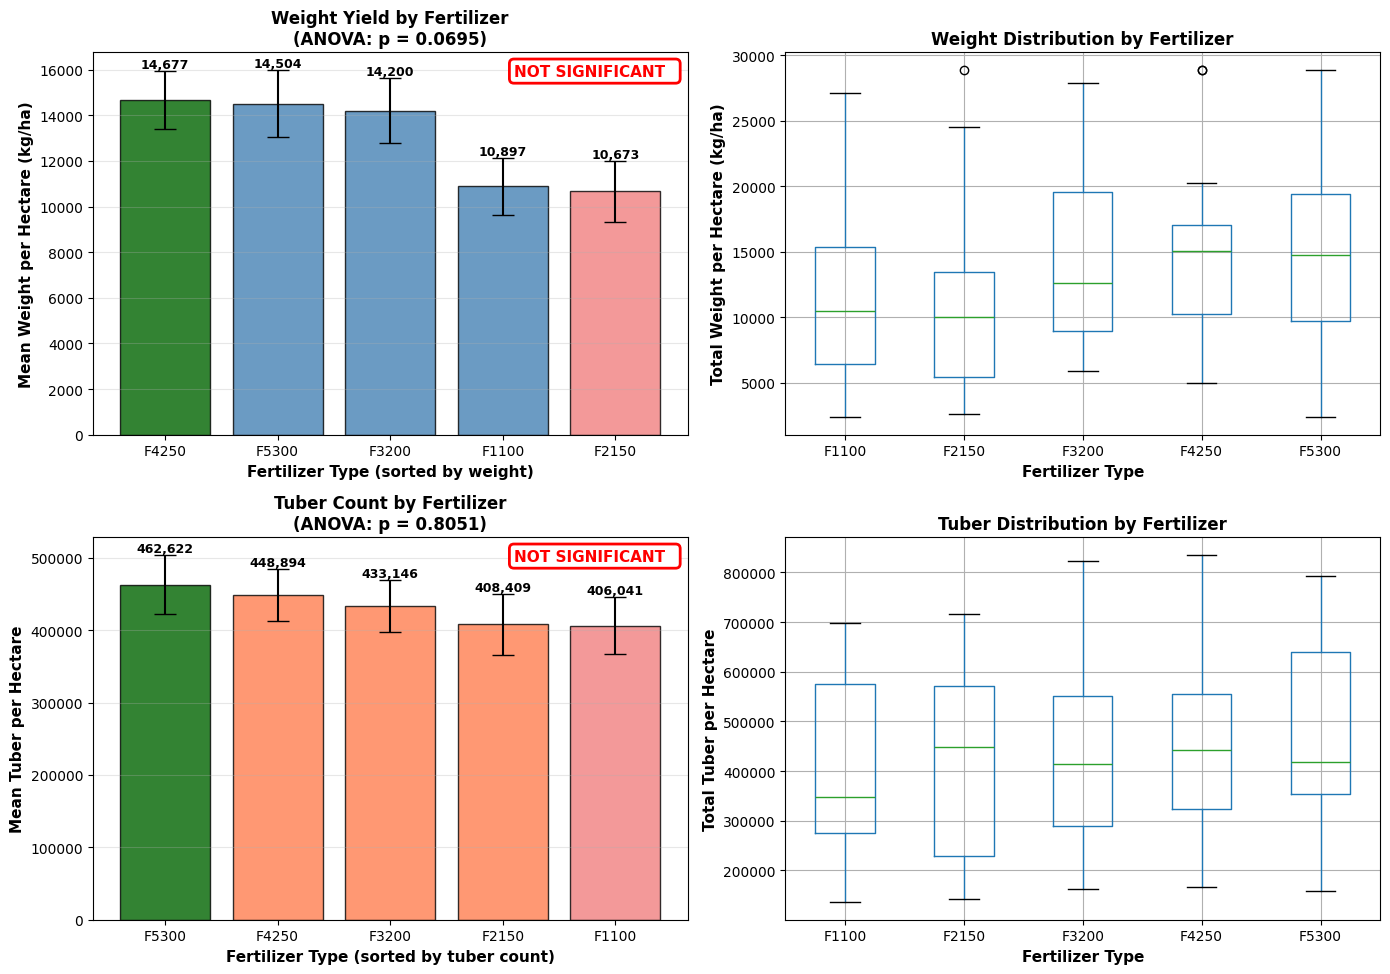

In [96]:
## visualizing the results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Question 3a: Effect of Fertilizer on Cassava Yields', 
             fontsize=16, fontweight='bold', y=0.995)

### weight by fertilizer
means_w = data_cleaned.groupby('ferT')['TotalWeightperhectare'].mean().sort_values(ascending=False)
sem_w = data_cleaned.groupby('ferT')['TotalWeightperhectare'].sem().loc[means_w.index]
colors_w = ['darkgreen' if i == 0 else 'lightcoral' if i == len(means_w)-1 else 'steelblue' 
            for i in range(len(means_w))]

axes[0, 0].bar(range(len(means_w)), means_w.values, yerr=sem_w.values, 
               capsize=8, alpha=0.8, edgecolor='black', color=colors_w)
axes[0, 0].set_xticks(range(len(means_w)))
axes[0, 0].set_xticklabels(means_w.index, fontsize=10)
axes[0, 0].set_ylabel('Mean Weight per Hectare (kg/ha)', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Fertilizer Type (sorted by weight)', fontweight='bold', fontsize=11)
axes[0, 0].set_title(f'Weight Yield by Fertilizer\n(ANOVA: p = {p_value_weight:.4f})', 
                     fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

for i, (idx, val) in enumerate(means_w.items()):
    axes[0, 0].text(i, val + sem_w[idx], f'{val:,.0f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

### significance annotation
sig_text = "SIGNIFICANT  " if p_value_weight < 0.05 else "NOT SIGNIFICANT  "
sig_color = "green" if p_value_weight < 0.05 else "red"
axes[0, 0].text(0.98, 0.97, sig_text, transform=axes[0, 0].transAxes,
                fontsize=11, fontweight='bold', color=sig_color,
                ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=sig_color, linewidth=2))

### Weight distribution
data_cleaned.boxplot(column='TotalWeightperhectare', by='ferT', ax=axes[0, 1])
axes[0, 1].set_xlabel('Fertilizer Type', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Total Weight per Hectare (kg/ha)', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Weight Distribution by Fertilizer', fontweight='bold', fontsize=12)
axes[0, 1].get_figure().suptitle('') 
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=0)

means_t = data_cleaned.groupby('ferT')['TotalTuberperHectare'].mean().sort_values(ascending=False)
sem_t = data_cleaned.groupby('ferT')['TotalTuberperHectare'].sem().loc[means_t.index]
colors_t = ['darkgreen' if i == 0 else 'lightcoral' if i == len(means_t)-1 else 'coral' 
            for i in range(len(means_t))]

axes[1, 0].bar(range(len(means_t)), means_t.values, yerr=sem_t.values, 
               capsize=8, alpha=0.8, edgecolor='black', color=colors_t)
axes[1, 0].set_xticks(range(len(means_t)))
axes[1, 0].set_xticklabels(means_t.index, fontsize=10)
axes[1, 0].set_ylabel('Mean Tuber per Hectare', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Fertilizer Type (sorted by tuber count)', fontweight='bold', fontsize=11)
axes[1, 0].set_title(f'Tuber Count by Fertilizer\n(ANOVA: p = {p_value_tuber:.4f})', 
                     fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(means_t.items()):
    axes[1, 0].text(i, val + sem_t[idx], f'{val:,.0f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

### adding significance annotation
sig_text_t = "SIGNIFICANT  " if p_value_tuber < 0.05 else "NOT SIGNIFICANT  "
sig_color_t = "green" if p_value_tuber < 0.05 else "red"
axes[1, 0].text(0.98, 0.97, sig_text_t, transform=axes[1, 0].transAxes,
                fontsize=11, fontweight='bold', color=sig_color_t,
                ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=sig_color_t, linewidth=2))

### Tuber distribution
data_cleaned.boxplot(column='TotalTuberperHectare', by='ferT', ax=axes[1, 1])
axes[1, 1].set_xlabel('Fertilizer Type', fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('Total Tuber per Hectare', fontweight='bold', fontsize=11)
axes[1, 1].set_title('Tuber Distribution by Fertilizer', fontweight='bold', fontsize=12)
axes[1, 1].get_figure().suptitle('')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('q3a_fertilizer_effect.png', dpi=300, bbox_inches='tight')
print("\n  Visualization saved: q3a_fertilizer_effect.png")
plt.show()

### b) Does the tillage method (“conv” and “minimum”) affect the projected “TotalWeightperhectare” and "TotalTuberperHectare?"

In [101]:
conv_weight = data_cleaned[data_cleaned['tillage '] == 'conv']['TotalWeightperhectare']
min_weight = data_cleaned[data_cleaned['tillage '] == 'minimum']['TotalWeightperhectare']

conv_tuber = data_cleaned[data_cleaned['tillage '] == 'conv']['TotalTuberperHectare']
min_tuber = data_cleaned[data_cleaned['tillage '] == 'minimum']['TotalTuberperHectare']

print(f"  Conventional tillage: n = {len(conv_weight)}")
print(f"  Minimum tillage:      n = {len(min_weight)}")
print(f"  Total:                n = {len(data_cleaned)}")
print(f"\n  ✓ BOTH GROUPS > 30 observations")
print(f"  -> Central Limit Theorem applies")
print(f"  -> Sampling distribution of means will be approximately normal")

  Conventional tillage: n = 60
  Minimum tillage:      n = 55
  Total:                n = 115

  ✓ BOTH GROUPS > 30 observations
  → Central Limit Theorem applies
  → Sampling distribution of means will be approximately normal


In [102]:
print("Weight Comparison (kg/ha):")
print(f"  Conventional: {conv_weight.mean():>10,.2f} ± {conv_weight.std():.2f} (Mean ± SD)")
print(f"  Minimum:      {min_weight.mean():>10,.2f} ± {min_weight.std():.2f} (Mean ± SD)")
print(f"  Difference:   {conv_weight.mean() - min_weight.mean():>10,.2f} ({((conv_weight.mean() - min_weight.mean()) / min_weight.mean() * 100):.1f}%)")

Weight Comparison (kg/ha):
  Conventional:  13,288.88 ± 6474.96 (Mean ± SD)
  Minimum:       12,664.44 ± 6821.88 (Mean ± SD)
  Difference:       624.44 (4.9%)


In [105]:
print("Checking Test Assumptions")
print("\nA. NORMALITY TESTS")
print("With n > 30, t-test is robust to violations of normality (CLT)")
print("We test anyway to confirm and guide interpretation.\n")

### shapiro-Wilk test
print("Shapiro-Wilk Test:")
w_conv, p_conv = shapiro(conv_weight)
w_min, p_min = shapiro(min_weight)
print(f"  Conventional: W = {w_conv:.4f}, p = {p_conv:.4f} {'(Normal)' if p_conv > 0.05 else '(Not Normal)'}")
print(f"  Minimum:      W = {w_min:.4f}, p = {p_min:.4f} {'(Normal)' if p_min > 0.05 else '(Not Normal)'}")

### D'Agostino-Pearson test (alternative normality test)
print("\nD'Agostino-Pearson Test:")
k2_conv, p_dag_conv = normaltest(conv_weight)
k2_min, p_dag_min = normaltest(min_weight)
print(f"  Conventional: K² = {k2_conv:.4f}, p = {p_dag_conv:.4f} {'(Normal)' if p_dag_conv > 0.05 else '(Not Normal)'}")
print(f"  Minimum:      K² = {k2_min:.4f}, p = {p_dag_min:.4f} {'(Normal)' if p_dag_min > 0.05 else '(Not Normal)'}")

if p_conv < 0.05 or p_min < 0.05:
    print("\n Data may not be perfectly normal, BUT:")
    print("With n > 30, t-test is ROBUST to this (CLT)")
    print("We'll also run Mann-Whitney U test (doesn't assume normality)")
else:
    print("\nData appears normal - both tests appropriate")

print("\nB. EQUALITY OF VARIANCES")
levene_stat, levene_p = levene(conv_weight, min_weight)
print(f"Levene's Test: F = {levene_stat:.4f}, p = {levene_p:.4f}")
print(f"Interpretation: {'Equal variances ' if levene_p > 0.05 else 'Unequal variances'}")

### Variance ratio (rule of thumb: should be < 2)
var_ratio = max(conv_weight.var(), min_weight.var()) / min(conv_weight.var(), min_weight.var())
print(f"\nVariance Ratio: {var_ratio:.4f}")
print(f"Rule of thumb: {' OK' if var_ratio < 2 else '⚠ Large difference'} (should be < 2)")

Checking Test Assumptions

A. NORMALITY TESTS
With n > 30, t-test is robust to violations of normality (CLT)
We test anyway to confirm and guide interpretation.

Shapiro-Wilk Test:
  Conventional: W = 0.9558, p = 0.0294 (Not Normal)
  Minimum:      W = 0.9414, p = 0.0098 (Not Normal)

D'Agostino-Pearson Test:
  Conventional: K² = 3.5364, p = 0.1706 (Normal)
  Minimum:      K² = 4.2512, p = 0.1194 (Normal)

 Data may not be perfectly normal, BUT:
With n > 30, t-test is ROBUST to this (CLT)
We'll also run Mann-Whitney U test (doesn't assume normality)

B. EQUALITY OF VARIANCES
Levene's Test: F = 0.0035, p = 0.9530
Interpretation: Equal variances 

Variance Ratio: 1.1100
Rule of thumb:  OK (should be < 2)


In [108]:
print("PARAMETRIC TEST - Independent t-test")

print("\nWhy t-test (not z-test) with n > 30?")
print("1. We don't know the population standard deviation ")
print("2. t-test uses sample SD, which is more appropriate")
print("3. With large n, t-distribution ≈ normal distribution anyway")
print("4. t-test is the standard choice in research/practice")

### performing t-test
t_stat, p_t = ttest_ind(conv_weight, min_weight, equal_var=(levene_p > 0.05))
df_degrees = len(conv_weight) + len(min_weight) - 2

print("\nIndependent samples t-test Results:")
print(f"  t-statistic:     {t_stat:.4f}")
print(f"  df (degrees):    {df_degrees}")
print(f"  P-value:         {p_t:.6f}")
print(f"  Alpha (α):       0.05")

### effect size (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d = cohens_d(conv_weight, min_weight)
print(f"\n  Effect Size (d): {d:.4f}")
if abs(d) < 0.2:
    print(f"  Interpretation:  Negligible effect")
elif abs(d) < 0.5:
    print(f"  Interpretation:  Small effect")
elif abs(d) < 0.8:
    print(f"  Interpretation:  Medium effect")
else:
    print(f"  Interpretation:  Large effect")

print("CONCLUSION (Parametric):")
if p_t < 0.05:
    print(f"  SIGNIFICANT (p < 0.05)")
    print(f"  -> Tillage method DOES affect yield")
else:
    print(f"  NOT SIGNIFICANT (p ≥ 0.05)")
    print(f"  -> Tillage method does NOT significantly affect yield")

PARAMETRIC TEST - Independent t-test

Why t-test (not z-test) with n > 30?
1. We don't know the population standard deviation 
2. t-test uses sample SD, which is more appropriate
3. With large n, t-distribution ≈ normal distribution anyway
4. t-test is the standard choice in research/practice

Independent samples t-test Results:
  t-statistic:     0.5035
  df (degrees):    113
  P-value:         0.615567
  Alpha (α):       0.05

  Effect Size (d): 0.0940
  Interpretation:  Negligible effect
CONCLUSION (Parametric):
  NOT SIGNIFICANT (p ≥ 0.05)
  -> Tillage method does NOT significantly affect yield


In [110]:
print("NON-PARAMETRIC TEST - Mann-Whitney U")

print("\nWhy also use Mann-Whitney U?")
print("1. Doesn't assume normal distribution")
print("2. More robust to outliers")
print("3. Validates t-test results")
print("4. If both tests agree -> stronger confidence in conclusion")

### performing Mann-Whitney U test
u_stat, p_u = mannwhitneyu(conv_weight, min_weight, alternative='two-sided')

print("\nMann-Whitney U Test Results:")
print(f"  U-statistic:     {u_stat:.4f}")
print(f"  P-value:         {p_u:.6f}")
print(f"  Alpha (α):       0.05")

### computing rank-biserial correlation (effect size for Mann-Whitney)
n1, n2 = len(conv_weight), len(min_weight)
r_rb = 1 - (2*u_stat) / (n1 * n2)
print(f"\n  Effect Size (r): {abs(r_rb):.4f}")
if abs(r_rb) < 0.1:
    print(f"  Interpretation:  Negligible effect")
elif abs(r_rb) < 0.3:
    print(f"  Interpretation:  Small effect")
elif abs(r_rb) < 0.5:
    print(f"  Interpretation:  Medium effect")
else:
    print(f"  Interpretation:  Large effect")

print("CONCLUSION (Non-parametric):")
if p_u < 0.05:
    print(f"  SIGNIFICANT (p < 0.05)")
    print(f"  -> Tillage method DOES affect yield")
else:
    print(f"  NOT SIGNIFICANT (p ≥ 0.05)")
    print(f"  -> Tillage method does NOT significantly affect yield")

NON-PARAMETRIC TEST - Mann-Whitney U

Why also use Mann-Whitney U?
1. Doesn't assume normal distribution
2. More robust to outliers
3. Validates t-test results
4. If both tests agree -> stronger confidence in conclusion

Mann-Whitney U Test Results:
  U-statistic:     1777.0000
  P-value:         0.478694
  Alpha (α):       0.05

  Effect Size (r): 0.0770
  Interpretation:  Negligible effect
CONCLUSION (Non-parametric):
  NOT SIGNIFICANT (p ≥ 0.05)
  -> Tillage method does NOT significantly affect yield


In [111]:
print("Comparison of Both Tests")

### creating a comparison table
comparison_data = {
    'Test': ['t-test (Parametric)', 'Mann-Whitney U (Non-parametric)'],
    'Test Statistic': [f't = {t_stat:.4f}', f'U = {u_stat:.4f}'],
    'P-value': [f'{p_t:.6f}', f'{p_u:.6f}'],
    'Significant?': ['Yes' if p_t < 0.05 else 'No', 'Yes' if p_u < 0.05 else 'No'],
    'Effect Size': [f'd = {d:.4f}', f'r = {abs(r_rb):.4f}']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

Comparison of Both Tests

                           Test Test Statistic  P-value Significant? Effect Size
            t-test (Parametric)     t = 0.5035 0.615567           No  d = 0.0940
Mann-Whitney U (Non-parametric)  U = 1777.0000 0.478694           No  r = 0.0770


In [114]:
print("AGREEMENT BETWEEN TESTS:")
if (p_t < 0.05) == (p_u < 0.05):
    print("  BOTH TESTS AGREE")
    print("  -> Strong confidence in the conclusion")
    print("  -> Results are robust regardless of assumptions")
    if p_t < 0.05:
        print("  -> Clear evidence that tillage DOES affect yield")
    else:
        print("  -> Clear evidence that tillage does NOT affect yield")
else:
    print("  TESTS DISAGREE")
    print("  -> Consider:")
    if p_t < 0.05 and p_u >= 0.05:
        print("    • t-test says significant, Mann-Whitney says not")
        print("    • May be due to outliers or non-normality")
        print("    • Recommend trusting Mann-Whitney U (more robust)")
    else:
        print("    • Mann-Whitney says significant, t-test says not")
        print("    • May be due to distributional differences")
        print("    • Results are marginal - interpret cautiously")

AGREEMENT BETWEEN TESTS:
  BOTH TESTS AGREE
  -> Strong confidence in the conclusion
  -> Results are robust regardless of assumptions
  -> Clear evidence that tillage does NOT affect yield


In [116]:
print("Analysis for TotalTuberperHectare")

## t-test for tuber
t_stat_tuber, p_t_tuber = ttest_ind(conv_tuber, min_tuber)
d_tuber = cohens_d(conv_tuber, min_tuber)

## Mann-Whitney for tuber
u_stat_tuber, p_u_tuber = mannwhitneyu(conv_tuber, min_tuber, alternative='two-sided')
r_rb_tuber = 1 - (2*u_stat_tuber) / (len(conv_tuber) * len(min_tuber))

print("\nResults Summary:")
print(f"t-test:         t = {t_stat_tuber:.4f}, p = {p_t_tuber:.6f}, d = {d_tuber:.4f}")
print(f"Mann-Whitney U: U = {u_stat_tuber:.4f}, p = {p_u_tuber:.6f}, r = {abs(r_rb_tuber):.4f}")

if (p_t_tuber < 0.05) == (p_u_tuber < 0.05):
    print("\n Both tests agree:")
    if p_t_tuber < 0.05:
        print("  -> Tillage DOES affect tuber count")
    else:
        print("  -> Tillage does NOT affect tuber count")
else:
    print("\nTests disagree - interpret cautiously")

Analysis for TotalTuberperHectare

Results Summary:
t-test:         t = 1.3800, p = 0.170315, d = 0.2576
Mann-Whitney U: U = 1881.5000, p = 0.195867, r = 0.1403

 Both tests agree:
  -> Tillage does NOT affect tuber count


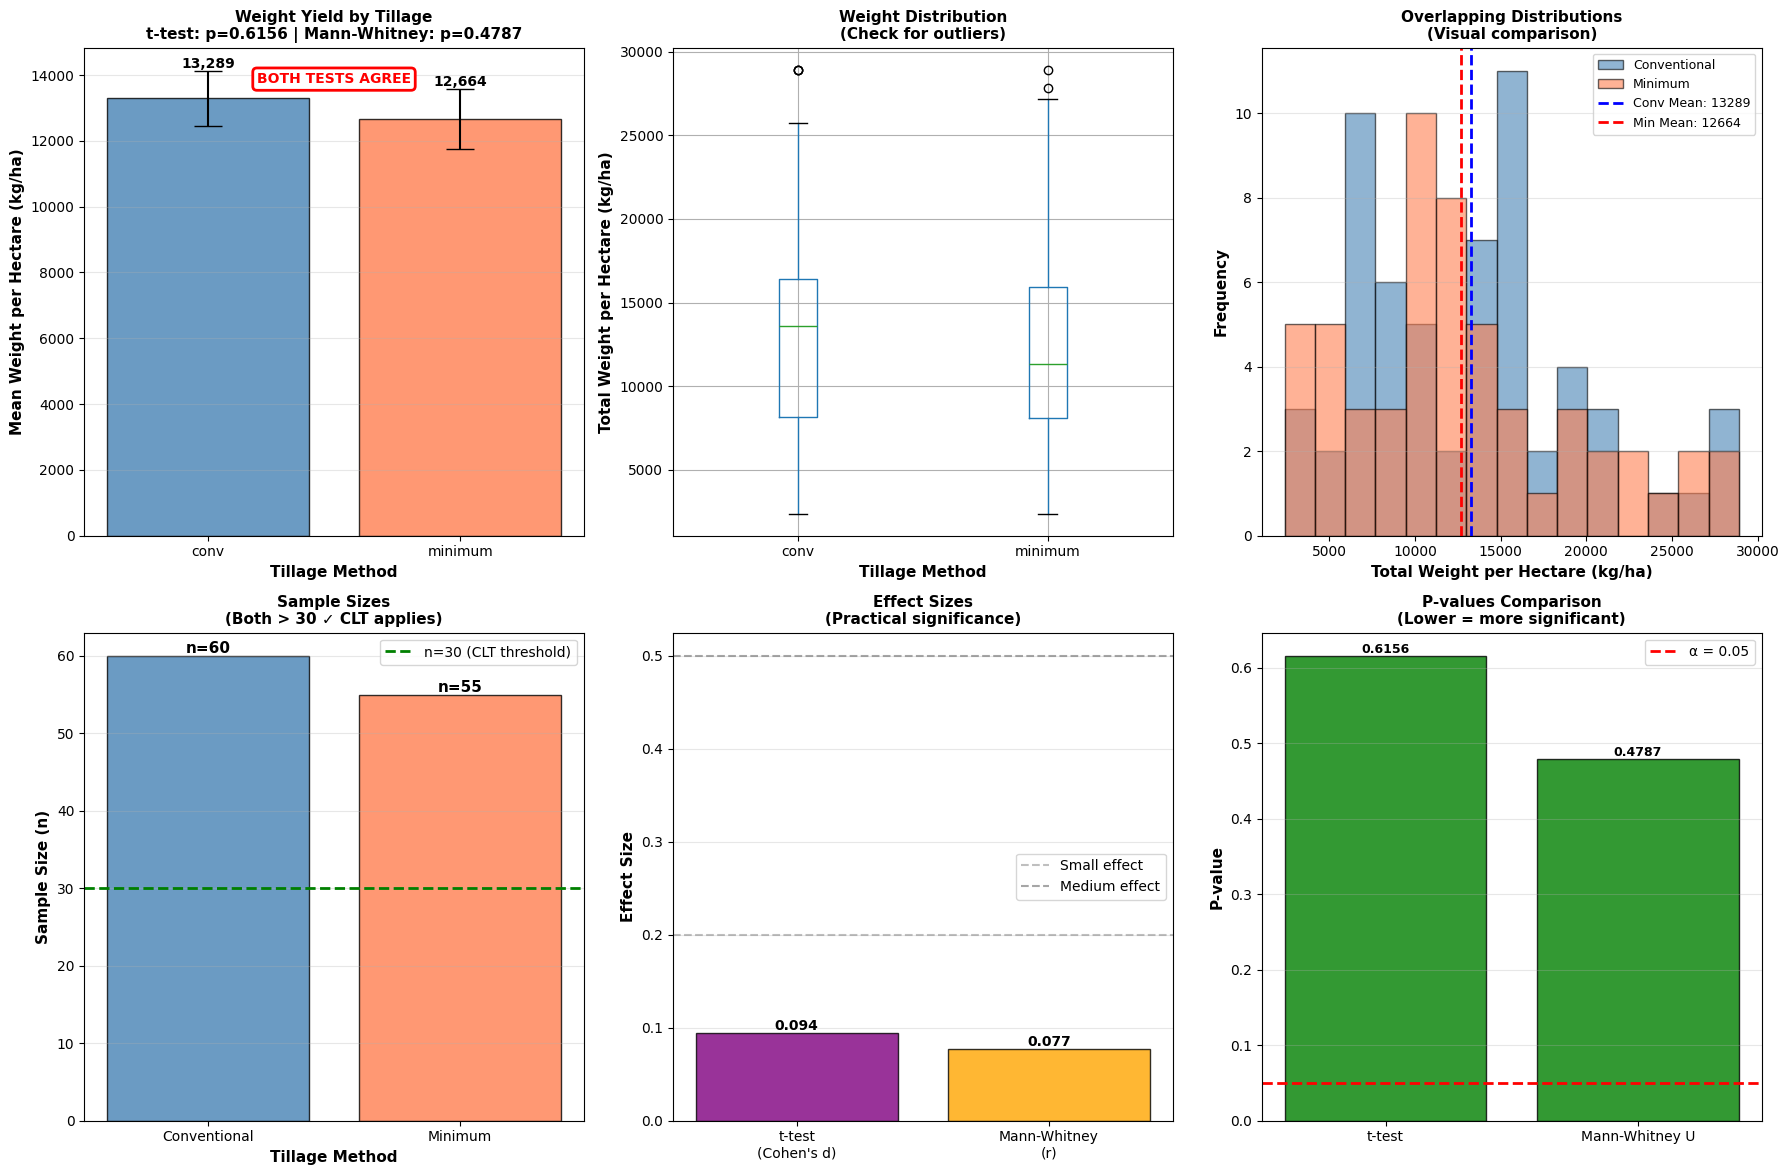

In [119]:
## visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Tillage Effect ', 
             fontsize=16, fontweight='bold', y=0.995)

### Bar chart with both test results
means_w = data_cleaned.groupby('tillage ')['TotalWeightperhectare'].mean()
sem_w = data_cleaned.groupby('tillage ')['TotalWeightperhectare'].sem()
colors = ['steelblue', 'coral']

axes[0, 0].bar(means_w.index, means_w.values, yerr=sem_w.values, 
               capsize=10, alpha=0.8, edgecolor='black', color=colors)
axes[0, 0].set_ylabel('Mean Weight per Hectare (kg/ha)', fontweight='bold', fontsize=11)
axes[0, 0].set_xlabel('Tillage Method', fontweight='bold', fontsize=11)
axes[0, 0].set_title(f'Weight Yield by Tillage\nt-test: p={p_t:.4f} | Mann-Whitney: p={p_u:.4f}', 
                     fontweight='bold', fontsize=11)
axes[0, 0].grid(True, alpha=0.3, axis='y')

for i, (idx, val) in enumerate(means_w.items()):
    axes[0, 0].text(i, val + sem_w[idx], f'{val:,.0f}', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

## Consensus annotation
if (p_t < 0.05) == (p_u < 0.05):
    consensus_text = "BOTH TESTS AGREE"
    consensus_color = "green" if p_t < 0.05 else "red"
else:
    consensus_text = "TESTS DISAGREE"
    consensus_color = "orange"

axes[0, 0].text(0.5, 0.95, consensus_text, transform=axes[0, 0].transAxes,
                fontsize=10, fontweight='bold', color=consensus_color,
                ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor=consensus_color, linewidth=2))

### Boxplot
data_cleaned.boxplot(column='TotalWeightperhectare', by='tillage ', ax=axes[0, 1])
axes[0, 1].set_xlabel('Tillage Method', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Total Weight per Hectare (kg/ha)', fontweight='bold', fontsize=11)
axes[0, 1].set_title('Weight Distribution\n(Check for outliers)', fontweight='bold', fontsize=11)
axes[0, 1].get_figure().suptitle('')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=0)

### Histogram overlay
axes[0, 2].hist(conv_weight, bins=15, alpha=0.6, label='Conventional', color='steelblue', edgecolor='black')
axes[0, 2].hist(min_weight, bins=15, alpha=0.6, label='Minimum', color='coral', edgecolor='black')
axes[0, 2].axvline(conv_weight.mean(), color='blue', linestyle='--', linewidth=2, label=f'Conv Mean: {conv_weight.mean():.0f}')
axes[0, 2].axvline(min_weight.mean(), color='red', linestyle='--', linewidth=2, label=f'Min Mean: {min_weight.mean():.0f}')
axes[0, 2].set_xlabel('Total Weight per Hectare (kg/ha)', fontweight='bold', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontweight='bold', fontsize=11)
axes[0, 2].set_title('Overlapping Distributions\n(Visual comparison)', fontweight='bold', fontsize=11)
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3, axis='y')

### Sample sizes
sample_sizes = [len(conv_weight), len(min_weight)]
axes[1, 0].bar(['Conventional', 'Minimum'], sample_sizes, alpha=0.8, edgecolor='black', color=colors)
axes[1, 0].axhline(y=30, color='green', linestyle='--', linewidth=2, label='n=30 (CLT threshold)')
axes[1, 0].set_ylabel('Sample Size (n)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Tillage Method', fontweight='bold', fontsize=11)
axes[1, 0].set_title('Sample Sizes\n(Both > 30 ✓ CLT applies)', fontweight='bold', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (label, val) in enumerate(zip(['Conventional', 'Minimum'], sample_sizes)):
    axes[1, 0].text(i, val, f'n={val}', ha='center', va='bottom', fontweight='bold', fontsize=11)

### Effect sizes comparison
effect_labels = ['t-test\n(Cohen\'s d)', 'Mann-Whitney\n(r)']
effect_values = [abs(d), abs(r_rb)]
axes[1, 1].bar(effect_labels, effect_values, alpha=0.8, edgecolor='black', color=['purple', 'orange'])
axes[1, 1].axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Small effect')
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Medium effect')
axes[1, 1].set_ylabel('Effect Size', fontweight='bold', fontsize=11)
axes[1, 1].set_title('Effect Sizes\n(Practical significance)', fontweight='bold', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, val in enumerate(effect_values):
    axes[1, 1].text(i, val, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

### P-value comparison
p_labels = ['t-test', 'Mann-Whitney U']
p_values = [p_t, p_u]
bars = axes[1, 2].bar(p_labels, p_values, alpha=0.8, edgecolor='black', 
                      color=['green' if p >= 0.05 else 'red' for p in p_values])
axes[1, 2].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1, 2].set_ylabel('P-value', fontweight='bold', fontsize=11)
axes[1, 2].set_title('P-values Comparison\n(Lower = more significant)', fontweight='bold', fontsize=11)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, val in enumerate(p_values):
    axes[1, 2].text(i, val, f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 4) Association between fertilisers across seasons

In [ ]:
ct_fs = pd.crosstab(data_cleaned["ferT"], data_cleaned["Sesn"])
chi2, p, dof, exp = stats.chi2_contingency(ct_fs)
n = ct_fs.values.sum()
cramer_v = np.sqrt(chi2/(n*(min(ct_fs.shape)-1))) if min(ct_fs.shape) > 1 else np.nan
print(f'Chi-square = {chi2:.3f}, p = {p:.4g}, CramerV = {cramer_v:.3f}')
display(ct_fs)

## lift (deviation from independence)
fert_probs = ct_fs.sum(axis=1)/n
season_probs = ct_fs.sum(axis=0)/n
lift = pd.DataFrame(index=ct_fs.index, columns=ct_fs.columns, dtype=float)
for f in ct_fs.index:
    for s in ct_fs.columns:
        joint = ct_fs.loc[f, s] / n
        denom = fert_probs.loc[f] * season_probs.loc[s]
        lift.loc[f, s] = joint/denom if denom>0 else np.nan
print('Lift (>1: positive association, <1: negative, ~1: independent)')
lift

Chi-square = 0.000, p = 1, CramerV = 0.000


Sesn,1,2
ferT,,
F1100,11,12
F2150,11,12
F3200,11,12
F4250,11,12
F5300,11,12


Lift (>1: positive association, <1: negative, ~1: independent)


Sesn,1,2
ferT,,
F1100,1.0,1.0
F2150,1.0,1.0
F3200,1.0,1.0
F4250,1.0,1.0
F5300,1.0,1.0


### Association analysis between fertiliser application and season

To determine whether fertiliser application codes (*ferT*) show any association with cassava seasons (*Sesn*), a Chi-square test of independence, Cramér’s V statistic, and Lift values were computed.

#### **Results**
- **Chi-square = 0.000**  
- **p-value = 1.000**  
- **Cramér’s V = 0.000**  
- **All Lift values = 1.0**

#### **Interpretation**
The Chi-square statistic of **0.0** with a **p-value of 1.0** indicates **no statistical association** between fertiliser type and season.  
Cramér’s V = **0.000** further confirms that the strength of association is **zero**, meaning the variables are completely independent.  
Lift values of **1.0** across all fertiliser-season combinations show that the likelihood of applying a given fertiliser in either season is exactly as expected under perfect independence.

#### **Practical Meaning**
The contingency table shows balanced frequencies (11 vs. 12) for each fertiliser across Seasons 1 and 2.  
This perfect balance demonstrates that **fertilisers were applied uniformly across seasons**, with no fertiliser disproportionately used in one season over the other.

#### **Conclusion**
There is **no association** between fertiliser application and season.  
This confirms that the experimental design was well controlled and free from seasonal treatment bias.  
As a result, any observed differences in cassava yield can be attributed to fertiliser effects themselves rather than unequal seasonal distribution.

### 5) Predictive model for `Plants_harvested`
- I am to compare two models **Linear Regression** and **Random Forest**. 

In [122]:
## target and features
target = [c for c in data_cleaned.columns if c.lower().replace(' ', '_') == 'plants_harvested']
target = target[0] if target else None
target

'Plants_harvested'

In [123]:
if target is None:
    raise ValueError('Plants_harvested column not found.')

X = data_cleaned.drop(columns=[target])
y = data_cleaned[target].astype(float)

num_X = X.select_dtypes(include=[np.number]).columns.tolist()
cat_X = [c for c in X.columns if c not in num_X]

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_X),
    ('cat', Pipeline(steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_X)
])


In [124]:
def metrics_all(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/np.where(y_true==0, np.nan, y_true)))*100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape, 'R2': r2}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
def train_eval(model):
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    m = metrics_all(y_test, pred)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(pipe, X, y, cv=cv, scoring=make_scorer(r2_score))
    m['CV_R2_mean'] = float(np.mean(cv_r2))
    m['CV_R2_std']  = float(np.std(cv_r2))
    return m, pipe

In [126]:
lin_m, lin_pipe = train_eval(LinearRegression())
rf_m,  rf_pipe  = train_eval(RandomForestRegressor(random_state=42, n_estimators=300))

print('LinearRegression:', lin_m)
print('RandomForestRegressor:', rf_m)

LinearRegression: {'MAE': 0.7904738414538641, 'RMSE': np.float64(1.0394313637634027), 'MAPE_%': np.float64(5.1220495751489175), 'R2': 0.9730983192817677, 'CV_R2_mean': 0.9529491018836781, 'CV_R2_std': 0.049984117802238666}
RandomForestRegressor: {'MAE': 1.1948275862068969, 'RMSE': np.float64(1.6870056676269245), 'MAPE_%': np.float64(8.532277893008384), 'R2': 0.9291367831859572, 'CV_R2_mean': 0.8676156725917699, 'CV_R2_std': 0.12716004331162103}


In [127]:
best_pipe = lin_pipe if lin_m['R2'] >= rf_m['R2'] else rf_pipe
best_name = 'LinearRegression' if best_pipe is lin_pipe else 'RandomForestRegressor'
print('Best model:', best_name)

Best model: LinearRegression


In [128]:
## saving predictions & report quick residual check
pred = best_pipe.predict(X_test)
preds = pd.DataFrame({'y_true': y_test.reset_index(drop=True), 'y_pred': pred})
PRED_PATH = 'Plants_harvested_predictions.csv'
preds.to_csv(PRED_PATH, index=False)
print('Saved predictions to:', PRED_PATH)

Saved predictions to: Plants_harvested_predictions.csv


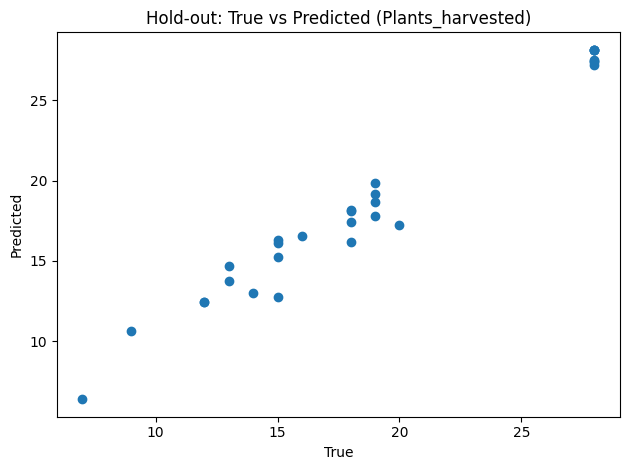

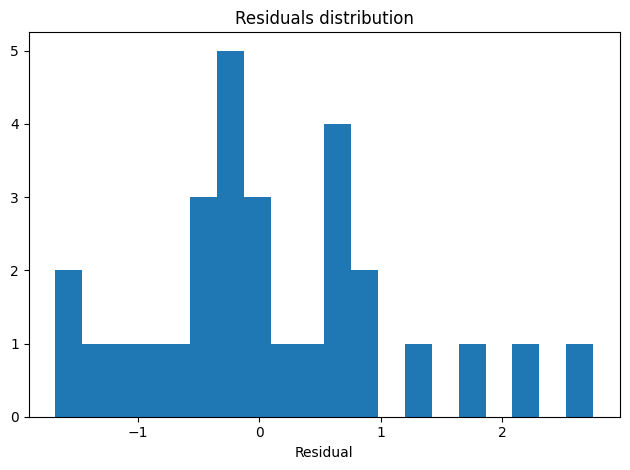

In [129]:
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel('True'); plt.ylabel('Predicted')
plt.title('Hold-out: True vs Predicted (Plants_harvested)')
plt.tight_layout()
plt.show()

resid = y_test - pred
plt.figure()
plt.hist(resid, bins=20)
plt.title('Residuals distribution')
plt.xlabel('Residual')
plt.tight_layout()
plt.show()

From the results: 
- The **Linear Regression** wins with **R² = 0.97**, **MAPE = 5%** on which is a very strong accuracy for decision support.